# ECG Rhythm Classification with a 1D Convolutional Neural Network

Single-lead ECG rhythm classifier (Keras 3 with the PyTorch backend) trained on the
**Chapman–Shaoxing** 12-lead ECG database, using **lead I only** to emulate
smartwatch-grade single-lead recordings.

**Task** — 5-class rhythm classification:
`SR` (sinus rhythm), `AFIB` (atrial fibrillation), `SB` (sinus bradycardia),
`SVT` (supraventricular tachycardia), `ST` (sinus tachycardia).

**Pipeline** — per-record z-score scaling → stratified 80/10/10 train/validation/test
split → 1D-CNN → EarlyStopping on the validation set (test set kept untouched) →
evaluation with per-class precision / recall / F1 and macro-F1.

**Data** — Chapman–Shaoxing 12-lead ECG database (Zheng et al., 2020). The source used
here is the original **ChapmanECG** collection on figshare:
https://figshare.com/collections/ChapmanECG/4560497 .
A larger, merged *Chapman-Shaoxing-Ningbo* version is also available on PhysioNet
(https://doi.org/10.13026/wgex-er52). The raw data is **not** redistributed in this
repository; see the README for how to download it (`Diagnostics.xlsx` and the
`ECGData/` folder are expected next to this notebook).

> ⚠️ Research / educational project. **Not a medical device and not for clinical use.**

## 1. Setup and configuration

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # use the PyTorch backend for Keras 3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

keras.utils.set_random_seed(0)          # reproducibility

# --- Configuration -------------------------------------------------------
N_SAMPLES   = 5000                       # samples per record (10 s at 500 Hz)
N_LEADS     = 1                          # number of leads used (lead I only)
LEAD_INDEX  = 0                          # first lead column in the CSV files
RHYTHMS     = ["SR", "AFIB", "SB", "SVT", "ST"]   # target rhythm classes
N_CLASSES   = len(RHYTHMS)

# Class-weighting switch: compensate the class imbalance in the loss function.
# An A/B test on this 5-class setup showed no measurable benefit, so it is OFF
# by default. It is kept as a switch for future use (e.g. when adding classes).
USE_WEIGHTS = False

print("Keras", keras.__version__, "| backend:", keras.config.backend())

Keras 3.14.1 | backend: torch


## 2. Data loading and dataset construction

In [2]:
# Map each rhythm name to an integer class index
LABEL = {name: i for i, name in enumerate(RHYTHMS)}

# Diagnosis table: file name -> rhythm label
diagnostics = pd.read_excel("Diagnostics.xlsx", usecols=["FileName", "Rhythm"])

# Keep only the records belonging to the target rhythm classes
subset = diagnostics[diagnostics["Rhythm"].isin(RHYTHMS)].reset_index(drop=True)
print(subset["Rhythm"].value_counts(), "\n")

# Load the raw single-lead signals into the feature matrix X and labels y
lead_cols = list(range(LEAD_INDEX, LEAD_INDEX + N_LEADS))
X = np.zeros((len(subset), N_LEADS * N_SAMPLES), dtype=float)
y = np.zeros((len(subset),), dtype=int)

for i, row in subset.iterrows():
    record = pd.read_csv(f"ECGData/{row['FileName']}.csv",
                         header=0, usecols=lead_cols, nrows=N_SAMPLES)
    X[i] = record.values.T.flatten()
    y[i] = LABEL[row["Rhythm"]]

y = y.reshape(-1, 1)
print("X:", X.shape, " y:", y.shape)

Rhythm
SB      3889
SR      1826
AFIB    1780
ST      1568
SVT      587
Name: count, dtype: int64 

X: (9650, 5000)  y: (9650, 1)


## 3. Per-record scaling (z-score)

Each ECG record is standardised independently (zero mean, unit variance).

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
for i in range(len(X)):
    X[i] = scaler.fit_transform(X[i].reshape(-1, 1)).ravel()

## 4. One-hot encoding of the labels

In [4]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
Y = ohe.fit_transform(y).toarray()      # dense one-hot matrix, shape (n, N_CLASSES)
print("Y:", Y.shape)

Y: (9650, 5)


## 5. Train / validation / test split (80 / 10 / 10, stratified)

In [5]:
from sklearn.model_selection import train_test_split

# Three independent subsets:
#   train      - fits the model weights
#   validation - drives EarlyStopping (decides which epoch to keep)
#   test       - independent final estimate, touched only once at the very end
# EarlyStopping must NOT monitor the test set, otherwise it stops being independent.

y_int = np.argmax(Y, axis=1)            # integer labels (for stratification)

X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X, Y, test_size=0.10, random_state=0, stratify=y_int)

y_int_full = np.argmax(Y_train_full, axis=1)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.1111, random_state=0, stratify=y_int_full)

print("Train:", X_train.shape[0], " Val:", X_val.shape[0], " Test:", X_test.shape[0])

Train: 7720  Val: 965  Test: 965


## 6. Model definition and training

Class imbalance was evaluated with an A/B test (training with vs without class
weighting). For this 5-class setup it gave no measurable benefit, so weighting is
disabled by default and exposed through the `USE_WEIGHTS` switch in the
configuration cell above.

In [6]:
from keras.models import Sequential
from keras.layers import (Conv1D, Dense, MaxPooling1D,
                          GlobalAveragePooling1D, Input, SpatialDropout1D)
from keras.callbacks import EarlyStopping

# --- Architecture: 1D CNN ------------------------------------------------
model = Sequential([
    Input(shape=(N_LEADS * N_SAMPLES, 1)),

    Conv1D(filters=32, kernel_size=101, activation="relu"),
    MaxPooling1D(pool_size=11, padding="same"),
    SpatialDropout1D(0.25),

    Conv1D(filters=64, kernel_size=11, padding="same", activation="relu"),
    MaxPooling1D(pool_size=5, padding="same"),
    SpatialDropout1D(0.43),

    Conv1D(filters=128, kernel_size=5, padding="same", activation="relu"),
    SpatialDropout1D(0.43),

    GlobalAveragePooling1D(),
    Dense(N_CLASSES, activation="softmax"),
])

# --- Optional class weighting (controlled by USE_WEIGHTS) ----------------
if USE_WEIGHTS:
    from sklearn.utils.class_weight import compute_class_weight
    y_train_int = np.argmax(Y_train, axis=1)
    weights = compute_class_weight(class_weight="balanced",
                                   classes=np.unique(y_train_int), y=y_train_int)
    class_weight = dict(enumerate(weights))
    print("Class weighting ON:", class_weight)
else:
    class_weight = None
    print("Class weighting OFF")

# --- Training with EarlyStopping on the validation set -------------------
early_stop = EarlyStopping(monitor="val_loss", patience=30,
                           restore_best_weights=True, verbose=1)

model.compile(optimizer="adamw", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, Y_train,
                    validation_data=(X_val, Y_val),
                    epochs=800, batch_size=256, verbose=1,
                    class_weight=class_weight,
                    callbacks=[early_stop])

print("\nTrained epochs:", len(history.history["loss"]),
      "| best epoch:", int(np.argmin(history.history["val_loss"])) + 1)

Class weighting OFF
Epoch 1/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3860 - loss: 1.4702 - val_accuracy: 0.4031 - val_loss: 1.3953
Epoch 2/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4307 - loss: 1.3498 - val_accuracy: 0.4995 - val_loss: 1.1800
Epoch 3/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5255 - loss: 1.1582 - val_accuracy: 0.6477 - val_loss: 0.8937
Epoch 4/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6268 - loss: 0.9349 - val_accuracy: 0.7482 - val_loss: 0.6655
Epoch 5/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7035 - loss: 0.7503 - val_accuracy: 0.8456 - val_loss: 0.5011
Epoch 6/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7636 - loss: 0.6167 - val_accuracy: 0.8601 - val_loss: 0.4065
Epoch 7/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8026 - loss: 0.5364 - val_accuracy: 0.8933 - val_loss: 0.3475
Epoch 8/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8308 - loss: 0.462

## 7. Training history

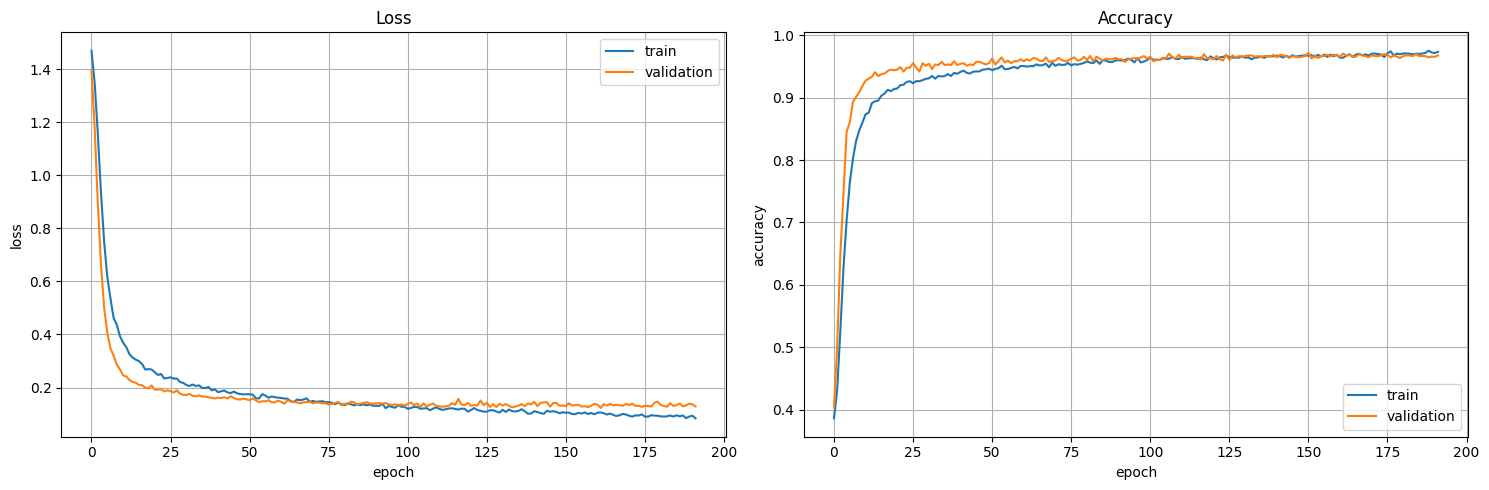

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
ax[1].legend(); ax[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Confusion matrix — training set

In [8]:
from sklearn.metrics import confusion_matrix

y_pred_train = np.argmax(model.predict(X_train), axis=1)
y_true_train = np.argmax(Y_train, axis=1)

cm_train = confusion_matrix(y_true_train, y_pred_train, normalize="true")
print("Row-normalised confusion matrix [%]  (rows = true, cols = predicted)")
print("classes:", RHYTHMS)
print(np.round(100 * cm_train, 1))

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Row-normalised confusion matrix [%]  (rows = true, cols = predicted)
classes: ['SR', 'AFIB', 'SB', 'SVT', 'ST']
[[98.1  0.5  0.9  0.   0.5]
 [ 0.1 98.6  0.1  0.2  0.9]
 [ 0.2  0.1 99.7  0.   0. ]
 [ 0.   0.4  0.  99.4  0.2]
 [ 0.4  0.3  0.1  0.2 99. ]]


## 9. Confusion matrix — test set

In [9]:
y_pred_test = np.argmax(model.predict(X_test), axis=1)
y_true_test = np.argmax(Y_test, axis=1)

cm_test = confusion_matrix(y_true_test, y_pred_test, normalize="true")
print("Row-normalised confusion matrix [%]  (rows = true, cols = predicted)")
print("classes:", RHYTHMS)
print(np.round(100 * cm_test, 1))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Row-normalised confusion matrix [%]  (rows = true, cols = predicted)
classes: ['SR', 'AFIB', 'SB', 'SVT', 'ST']
[[95.1  0.   3.3  0.   1.6]
 [ 0.6 96.6  1.1  0.6  1.1]
 [ 1.5  1.  97.4  0.   0. ]
 [ 0.   1.7  0.  96.6  1.7]
 [ 0.   3.2  0.   3.2 93.6]]


## 10. Test-set metrics (precision / recall / F1 / macro-F1)

In [10]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_true_test, y_pred_test, target_names=RHYTHMS, digits=3))

macro_f1    = f1_score(y_true_test, y_pred_test, average="macro")
weighted_f1 = f1_score(y_true_test, y_pred_test, average="weighted")
print(f"MACRO-F1   : {macro_f1*100:.2f} %")
print(f"WEIGHTED-F1: {weighted_f1*100:.2f} %\n")

# Absolute confusion matrix + manual per-class breakdown
# (absolute counts are needed to read precision = false-alarm rate)
cm = confusion_matrix(y_true_test, y_pred_test)
print("Absolute confusion matrix (rows = true, cols = predicted):")
print("classes:", RHYTHMS)
print(cm, "\n")

print(f"{'class':6}{'recall':>9}{'precision':>11}{'specificity':>13}{'F1':>8}{'support':>9}")
total = cm.sum()
for i, name in enumerate(RHYTHMS):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP            # rest of the row  = misses
    FP = cm[:, i].sum() - TP            # rest of the col  = false alarms
    TN = total - TP - FN - FP
    recall      = TP / (TP + FN) if (TP + FN) else 0.0
    precision   = TP / (TP + FP) if (TP + FP) else 0.0
    specificity = TN / (TN + FP) if (TN + FP) else 0.0
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    print(f"{name:6}{recall*100:8.1f}%{precision*100:10.1f}%"
          f"{specificity*100:12.1f}%{f1*100:7.1f}%{TP+FN:9d}")

              precision    recall  f1-score   support

          SR      0.961     0.951     0.956       182
        AFIB      0.945     0.966     0.956       178
          SB      0.979     0.974     0.977       389
         SVT      0.905     0.966     0.934        59
          ST      0.961     0.936     0.948       157

    accuracy                          0.962       965
   macro avg      0.950     0.959     0.954       965
weighted avg      0.962     0.962     0.962       965

MACRO-F1   : 95.42 %
WEIGHTED-F1: 96.17 %

Absolute confusion matrix (rows = true, cols = predicted):
classes: ['SR', 'AFIB', 'SB', 'SVT', 'ST']
[[173   0   6   0   3]
 [  1 172   2   1   2]
 [  6   4 379   0   0]
 [  0   1   0  57   1]
 [  0   5   0   5 147]] 

class    recall  precision  specificity      F1  support
SR        95.1%      96.1%        99.1%   95.6%      182
AFIB      96.6%      94.5%        98.7%   95.6%      178
SB        97.4%      97.9%        98.6%   97.7%      389
SVT       96.6%     